## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 



In [10]:

import pandas as pd


df = pd.read_csv('data/golub.csv')


mapping = {
    'ALLB': 0, 'allB': 0,
    'ALLT': 0, 'allT': 0,
    'ALL': 1,  'all': 1,
    'AML': 1,  'aml': 1  
}

df['cancer'] = df['cancer'].replace(mapping)

print(df['cancer'].value_counts())



cancer
0    47
1    25
Name: count, dtype: int64


/var/folders/89/vy1sctd5199dh7fb1_5765v00000gn/T/ipykernel_22590/192502359.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['cancer'] = df['cancer'].replace(mapping)




2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 



Mean Squared Error: 1.649109613713977e-30


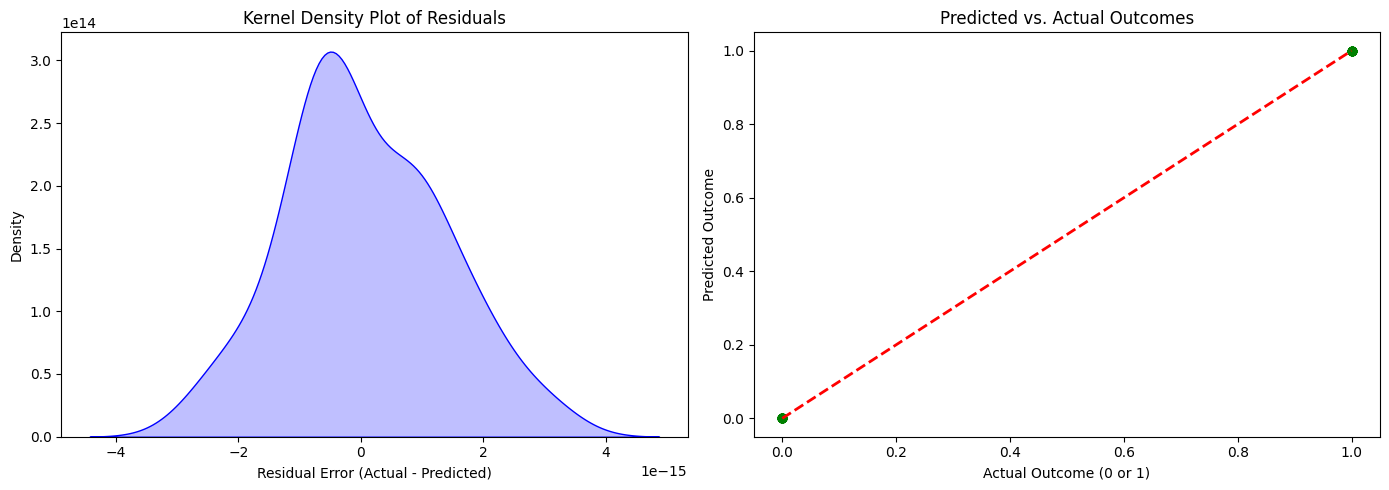

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

metadata_columns = ['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer']
X = df.drop(columns=metadata_columns)  
y = df['cancer']                       

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)
mse = mean_squared_error(y, predictions)
print(f"Mean Squared Error: {mse}")
residuals = y - predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  

sns.kdeplot(residuals, ax=axes[0], fill=True, color="blue")
axes[0].set_title('Kernel Density Plot of Residuals')
axes[0].set_xlabel('Residual Error (Actual - Predicted)')

axes[1].scatter(y, predictions, alpha=0.7, color="green")
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) 
axes[1].set_title('Predicted vs. Actual Outcomes')
axes[1].set_xlabel('Actual Outcome (0 or 1)')
axes[1].set_ylabel('Predicted Outcome')

plt.tight_layout() 
plt.show()




3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.


In [12]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)

mse_scores = -cv_scores

print(f"MSE array for the 5 folds: \n{mse_scores}\n")
print(f"Average Cross-Validation MSE: {np.mean(mse_scores)}")


MSE array for the 5 folds: 
[0.04872133 0.07295289 0.04721866 0.04686773 0.08485489]

Average Cross-Validation MSE: 0.06012309872062138


The cross validation results show a massive psike in Mean Squared Error compared to the first model, showing extreme high variance and low bias. The linear model perfectly memorizes the training data but fails completely when forced to predict on the unseen cross validation testing folds. To improve predictions we can try to introduce some bias into the model to reduce this extreme variance by using regression techniques.



4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 


How many genes are discarded from the model? -> 7095
How many genes are selected (kept)?            -> 34

Which set of genes is selected?
['HG3549-HT3751_at', 'J04164_at', 'L38941_at', 'M11147_at', 'M11722_at', 'M17733_at', 'M19507_at', 'M26602_at', 'M27891_at', 'M33680_at', 'M63138_at', 'M77232_rna1_at', 'M91036_rna1_at', 'M96326_rna1_at', 'U14968_at', 'X04500_at', 'X17042_at', 'X78992_at', 'Z70759_at', 'L06797_s_at', 'D49824_s_at', 'M25079_s_at', 'X57351_s_at', 'V00594_s_at', 'U05255_s_at', 'X03689_s_at', 'M14328_s_at', 'M14483_rna1_s_at', 'M26708_s_at', 'Y00787_s_at', 'Z19554_s_at', 'X56681_s_at', 'HG2887-HT3031_at', 'M33600_f_at']


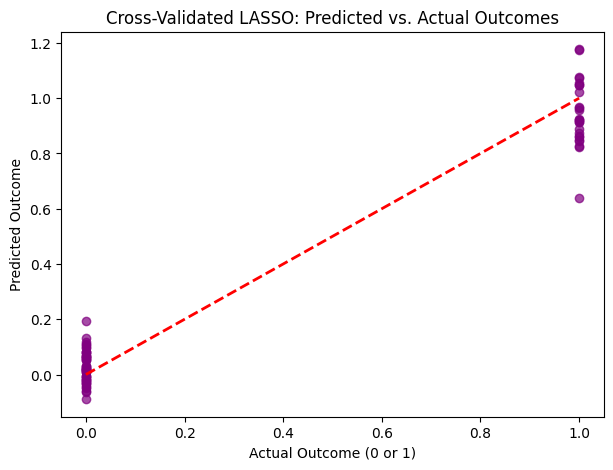

In [13]:
from sklearn.linear_model import LassoCV
import numpy as np
import matplotlib.pyplot as plt


lasso_model = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_model.fit(X, y)


lasso_coefs = lasso_model.coef_

discarded_count = np.sum(lasso_coefs == 0)
kept_count = np.sum(lasso_coefs != 0)

print(f"How many genes are discarded from the model? -> {discarded_count}")
print(f"How many genes are selected (kept)?            -> {kept_count}\n")

selected_genes = X.columns[lasso_coefs != 0]

print("Which set of genes is selected?")
print(list(selected_genes))
lasso_predictions = lasso_model.predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(y, lasso_predictions, alpha=0.7, color="purple")

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)

plt.title('Cross-Validated LASSO: Predicted vs. Actual Outcomes')
plt.xlabel('Actual Outcome (0 or 1)')
plt.ylabel('Predicted Outcome')
plt.show()




5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?



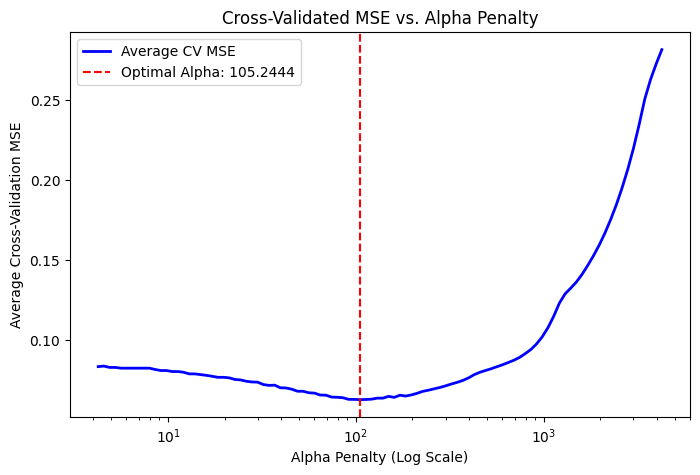

The optimal penalty hyperparameter is: 105.24436668425457


In [14]:
import numpy as np
import matplotlib.pyplot as plt

alphas = lasso_model.alphas_
mean_mses = np.mean(lasso_model.mse_path_, axis=1)

optimal_alpha = lasso_model.alpha_
plt.figure(figsize=(8, 5))

plt.semilogx(alphas, mean_mses, color='blue', linewidth=2, label='Average CV MSE')

plt.axvline(optimal_alpha, color='red', linestyle='--', label=f'Optimal Alpha: {optimal_alpha:.4f}')

plt.title('Cross-Validated MSE vs. Alpha Penalty')
plt.xlabel('Alpha Penalty (Log Scale)')
plt.ylabel('Average Cross-Validation MSE')
plt.legend()
plt.show()

print(f"The optimal penalty hyperparameter is: {optimal_alpha}")


LASSO is underfitting when the alpha is too high, causing the model to be too simple and not capture the underlying patterns in the data. LASSO is overfitting when the alpha is too low, causing the model to be too complex and capture the noise in the data. The optimal penalty alpha that minimizes the expected Mean Squared Error was found exactly at 105.24436668425457.



6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

This is because we have far more gene parameters (7,000+) than patient samples (around 70), unrestricted Linear Regression simply memorizes the training data, leading to perfect performance initially but terrible generalization on new patients (extreme overfitting/high variance). LASSO solves this by adding an L1 penalty that forces the vast majority of unhelpful gene coefficients to exactly zero. This greatly reduces the model's bloated variance, allowing the subset of genes left over to generalize significantly better overall.




7. Why do regularization methods lend themselves to scenarios like precision health? 

Precision health involves incredibly dense datasets measuring thousands of biological variables across a tiny number of patients. Regularization methods perfectly solve this challenge because they mathematically prevent these huge models from dangerously overfitting on small sample sizes, and techniques like LASSO inherently drop the unhelpful noise variables entirely. This accurately isolates the exact, handful of specific genes causing a disease, allowing doctors to build highly targeted precision treatments.


8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

The main risk is confusing mathematical correlation with biological causation. While a gene selected by Lasso might be highly predictive, it could just be a downstream side effect rather than the root cause, meaning medical interventions targeting it will fail. Furthermore, Lasso zeroes out highly correlated biological pathways, tricking doctors into treating only a single marker rather than the full, complex genetic picture.